# 🚢 Titanic Classification Project

## 🟢 TASK 1 — ১০ ধাপে পুরো Project

Step 0: Problem বোঝা

### 🎯 কী শিখবো?

#### যেকোনো ML project শুরুর আগে problem টা ভালোভাবে বোঝা — কী predict করতে চাই, data কোথা থেকে আসছে।

### 🔍 উদ্দেশ্য কী?

#### Titanic জাহাজ ডুবে যাওয়ার সময় কোন যাত্রী বেঁচে ছিলেন আর কে বাঁচেননি — সেটা predict করা।

Target Column: Survived

0 = মারা গেছেন ☠️
1 = বেঁচে গেছেন ✅

👉 এটা একটা Binary Classification Problem

Step 1: Library Import
🎯 কী শিখবো?
Python এ ML project এর জন্য কোন কোন library দরকার এবং কেন।
🔍 উদ্দেশ্য কী?
আমাদের tools গুলো load করা — এগুলো ছাড়া data পড়া, visualize করা বা model বানানো সম্ভব না।

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('ggplot')

In [14]:
df= pd.read_csv("Titanic-Dataset .csv")

In [15]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
df.shape

(891, 12)

In [18]:
df.describe()
#numeric column গুলোর mean, min, max, std দেখায়

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



## Step 4: Unnecessary Column বাদ দেওয়া

🎯 কী শিখবো?
সব column ML এর কাজে লাগে না — অপ্রয়োজনীয় column চেনা ও বাদ দেওয়া।
🔍 উদ্দেশ্য কী?
Noise কমানো। Name, Ticket, Cabin দিয়ে survival predict করা যায় না — এগুলো রাখলে model confused হয়।

In [19]:
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

print("নতুন shape:", df.shape)
print("বাকি columns:", df.columns.tolist())

নতুন shape: (891, 8)
বাকি columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']



## Step 5: Target Variable বোঝা

🎯 কী শিখবো?
Target class গুলো balanced কিনা সেটা দেখা এবং visualize করা।
🔍 উদ্দেশ্য কী?
যদি একটা class অনেক বেশি থাকে তাহলে model সবসময় সেটাই predict করবে — এটা জানা দরকার।

Survived
0    549
1    342
Name: count, dtype: int64


C:\Users\evan\AppData\Local\Temp\ipykernel_14856\2440432886.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df,palette='Set2')
C:\Users\evan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\evan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\evan\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\evan\AppData\Local\Progra

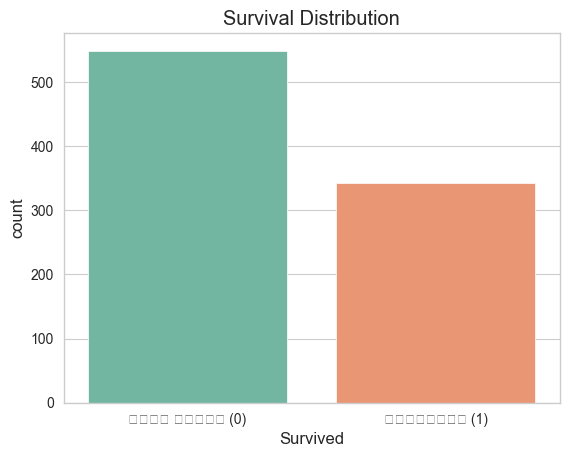

In [20]:
print(df['Survived'].value_counts())

sns.countplot(x='Survived', data=df,palette='Set2')
plt.title("Survival Distribution")
plt.xticks([0,1], ['মারা গেছেন (0)', 'বেঁচেছেন (1)'])
plt.show()


## Step 6: Data Visualization

## 🎯 কী শিখবো?

বিভিন্ন feature কীভাবে survival এর সাথে সম্পর্কিত সেটা চোখে দেখা।

## 🔍 উদ্দেশ্য কী?

"Women and children first" — এই ধারণাটা কি data তে সত্যি? Chart দেখে বুঝবো কোন feature গুরুত্বপূর্ণ।

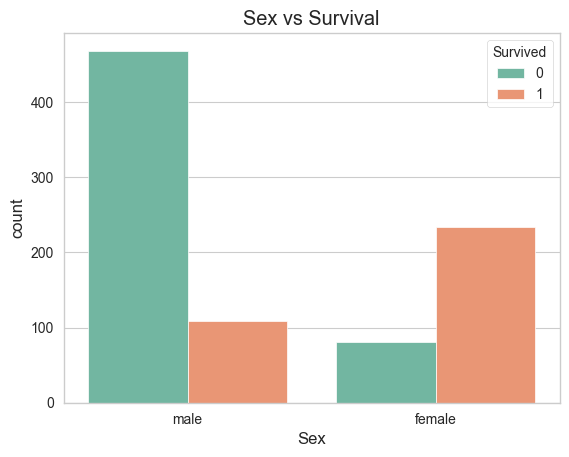

In [21]:
# Sex vs Survival
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2')
plt.title("Sex vs Survival")
plt.show()

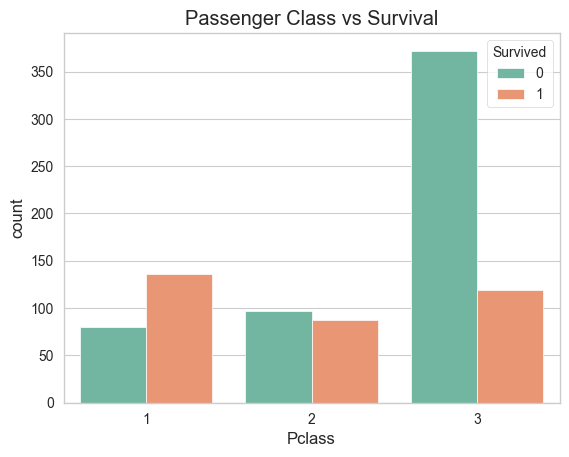

In [22]:
# Pclass vs Survival
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set2')
plt.title("Passenger Class vs Survival")
plt.show()

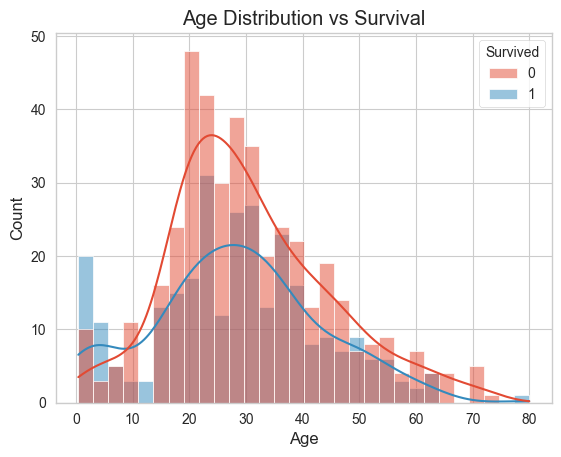

In [23]:
# Age distribution
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)
plt.title("Age Distribution vs Survival")
plt.show()


## Step 7: Encoding

🎯 কী শিখবো?
Categorical (text) data কে number এ বদলানো — ML এর জন্য এটা অপরিহার্য।
🔍 উদ্দেশ্য কী?
Machine Learning শুধু সংখ্যা বোঝে। male/female বা C/Q/S সরাসরি দেওয়া যায় না।

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded = df.copy()

# Sex encode করা
df_encoded['Sex'] = le.fit_transform(df_encoded['Sex'])

# Embarked encode করা
df_encoded['Embarked'] = le.fit_transform(df_encoded['Embarked'])

print("Sex encoding:")
print("female → 0, male → 1")
print("\nEmbarked encoding:")
print("C → 0, Q → 1, S → 2")

print("\nEncoded data (প্রথম ৩ row):")
print(df_encoded[['Sex', 'Embarked', 'Survived']].head(3))

Sex encoding:
female → 0, male → 1

Embarked encoding:
C → 0, Q → 1, S → 2

Encoded data (প্রথম ৩ row):
   Sex  Embarked  Survived
0    1         2         0
1    0         0         1
2    0         2         1



## Step 8: Feature & Target আলাদা করা

🎯 কী শিখবো?
Input (X) আর Output (y) আলাদা করার নিয়ম।
🔍 উদ্দেশ্য কী?
Model কে বলতে হবে — "এই তথ্যগুলো দিয়ে শেখো, এটা predict করো।"

In [25]:
X = df_encoded.drop('Survived', axis=1)
y = df_encoded['Survived']

print("Feature (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeatures:", X.columns.tolist())

Feature (X) shape: (891, 7)
Target (y) shape: (891,)

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']



## Step 9: Train-Test Split

🎯 কী শিখবো?
Data কে training ও testing ভাগে ভাগ করা এবং কেন এটা দরকার।
🔍 উদ্দেশ্য কী?
Model যে data দিয়ে শিখবে সেই একই data দিয়ে test করলে সে সব উত্তর আগেই জানে — এটা cheating! তাই আলাদা test set রাখতে হয়।

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (712, 7)
Testing set: (179, 7)



## tep 10: Model Train, Predict & Accuracy

🎯 কী শিখবো?
Decision Tree দিয়ে model বানানো, prediction করা এবং accuracy মাপা।
🔍 উদ্দেশ্য কী?
এতক্ষণ যা কিছু করলাম — load, clean, encode, split — সবকিছুর লক্ষ্য ছিল এই moment এর জন্য। Model train করে দেখবো সে কতটা ভালো predict করতে পারে।

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 81.56 %


## 🟢 TASK 2 — ৩টা TODO

### TODO 1: Missing Values
### 🎯 কী শিখবো?
Dataset এ কোথায় কোথায় data missing সেটা খুঁজে বের করা এবং সঠিক পদ্ধতিতে fill করা।
### 🔍 উদ্দেশ্য কী?
Missing data রেখে দিলে ML model error দেয় বা ভুল শেখে। তাই আগেই সব missing value handle করতে হয়।

In [33]:
# Step 1: Missing values খোঁজা
print("=== Missing Value Check ===")
print(df.isnull().sum())
print("\nPercentage missing:")
print(round(df.isnull().sum() / len(df) * 100, 2))

=== Missing Value Check ===
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Percentage missing:
Survived     0.00
Pclass       0.00
Sex          0.00
Age         19.87
SibSp        0.00
Parch        0.00
Fare         0.00
Embarked     0.22
dtype: float64


In [37]:
# Step 2: সিদ্ধান্ত ও Imputation apply করা

# Age: numeric → Mean দিয়ে fill
age_mean = df['Age'].mean()
df['Age'] = df['Age'].fillna(age_mean)
print(f"Age missing fill করা হয়েছে mean দিয়ে: {round(age_mean, 2)}")

# Embarked: categorical → Mode দিয়ে fill
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)
print(f"Embarked missing fill করা হয়েছে mode দিয়ে: {embarked_mode}")

# Verify
print("\nমিসিং ভ্যালু আছে কিনা এখন:")
print(df.isnull().sum())

Age missing fill করা হয়েছে mean দিয়ে: 29.7
Embarked missing fill করা হয়েছে mode দিয়ে: S

মিসিং ভ্যালু আছে কিনা এখন:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64



## TODO 2: Categorical Encoding

### 🎯 কী শিখবো?
কোন column এ কোন encoding method ব্যবহার করবো সেটা বুঝে সিদ্ধান্ত নেওয়া।
### 🔍 উদ্দেশ্য কী?
সব categorical data এক পদ্ধতিতে encode করা ঠিক না। Column এর nature বুঝে সঠিক method বেছে নিতে হয়।

In [39]:
print("Categorical columns:")
cat_cols =df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

Categorical columns:
['Sex', 'Embarked']


In [40]:
# Step 2: সিদ্ধান্ত
print("""
Encoding সিদ্ধান্ত:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Sex      → Label Encoding
           কারণ: মাত্র ২টা value (male/female)
           female=0, male=1

Embarked → Label Encoding
           কারণ: ৩টা value (C/Q/S), কোনো order নেই
           কিন্তু Decision Tree তে এটা চলবে
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


Encoding সিদ্ধান্ত:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Sex      → Label Encoding
           কারণ: মাত্র ২টা value (male/female)
           female=0, male=1

Embarked → Label Encoding
           কারণ: ৩টা value (C/Q/S), কোনো order নেই
           কিন্তু Decision Tree তে এটা চলবে
━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [42]:
# Step 3: Encoding apply করা
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded = df.copy()

df_encoded['Sex'] = le.fit_transform(df_encoded['Sex'])
df_encoded['Embarked'] = le.fit_transform(df_encoded['Embarked'])

print("Final encoded data:")
print(df_encoded.head(3))

Final encoded data:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2


## TODO 3: Feature Scaling
### 🎯 কী শিখবো?
Feature গুলোর value range কতটা ভিন্ন সেটা বোঝা এবং scaling কখন দরকার সিদ্ধান্ত নেওয়া।
### 🔍 উদ্দেশ্য কী?
Age (0–80) আর Fare (0–512) এর range অনেক আলাদা। KNN বা SVM এর মতো distance-based algorithm এ এই পার্থক্য ভুল result দেয় — Fare কে অনেক বেশি গুরুত্বপূর্ণ মনে হয়।

In [45]:
# Step 1: Value range চেক করা
X = df_encoded.drop('Survived', axis=1)

print("প্রতিটা numeric column এর range:")
print(X.describe().loc[['min', 'max']].T)

প্রতিটা numeric column এর range:
           min       max
Pclass    1.00    3.0000
Sex       0.00    1.0000
Age       0.42   80.0000
SibSp     0.00    8.0000
Parch     0.00    6.0000
Fare      0.00  512.3292
Embarked  0.00    2.0000


In [46]:
# Step 2: সিদ্ধান্ত
print("""
Scaling সিদ্ধান্ত:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Age  range: 0 → 80
Fare range: 0 → 512

পার্থক্য অনেক বেশি!
Decision Tree এর জন্য এখন না লাগলেও
ভবিষ্যতে KNN/SVM এর জন্য StandardScaler apply করবো ✅
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


Scaling সিদ্ধান্ত:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Age  range: 0 → 80
Fare range: 0 → 512

পার্থক্য অনেক বেশি!
Decision Tree এর জন্য এখন না লাগলেও
ভবিষ্যতে KNN/SVM এর জন্য StandardScaler apply করবো ✅
━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [47]:
# Step 3: StandardScaler apply করা
from sklearn.preprocessing import StandardScaler

y = df_encoded['Survived']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Before scaling (Age & Fare):")
print(X[['Age', 'Fare']].head(4))

print("\nAfter scaling (Mean≈0, সব একই range):")
print(X_scaled[['Age', 'Fare']].head(4))

Before scaling (Age & Fare):
    Age     Fare
0  22.0   7.2500
1  38.0  71.2833
2  26.0   7.9250
3  35.0  53.1000

After scaling (Mean≈0, সব একই range):
        Age      Fare
0 -0.592481 -0.502445
1  0.638789  0.786845
2 -0.284663 -0.488854
3  0.407926  0.420730
